# Team Humphrey

In [68]:
# Import dependencies
import pandas as pd
import os
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.imputation.mice as mice
import statsmodels.regression.linear_model as sm
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm, skew, probplot
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from numpy import sqrt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
import seaborn as sns
import xgboost as xgb

# Remove the limit on the number of columns displayed
pd.set_option('display.max_columns', None)

## Exploratory Data Analysis

### 1. Import and Explore Data

In [69]:
# Define the paths to train and test data
train_path = os.path.join(os.path.curdir, "Data", "train.csv")
test_path = os.path.join(os.path.curdir, "Data", "test.csv")

# Store the data in DataFrame
train_df = pd.read_csv(train_path, index_col="Id")
test_df = pd.read_csv(test_path, index_col="Id")

# Read the first three rows of the train data
print(train_df.head(3))
print("")

# Show the descriptive statistics
print(train_df.describe())
print("")

# Show the dtype and null-value count
print(train_df.info())

# Read the first three rows of the test data
print(test_df.head(3))
print("")

# Show the descriptive statistics
print(test_df.describe())
print("")

# Show the dtype and null-value count
print(test_df.info())

    MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                    
1           60       RL         65.0     8450   Pave   NaN      Reg   
2           20       RL         80.0     9600   Pave   NaN      Reg   
3           60       RL         68.0    11250   Pave   NaN      IR1   

   LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
Id                                                                     
1          Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
2          Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
3          Lvl    AllPub    Inside       Gtl      CollgCr       Norm   

   Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
Id                                                                       
1        Norm     1Fam     2Story            7            5       2003   
2        Norm     1Fam     1Story            6            8  

### 2. Exploring and Visualizing Missing Data

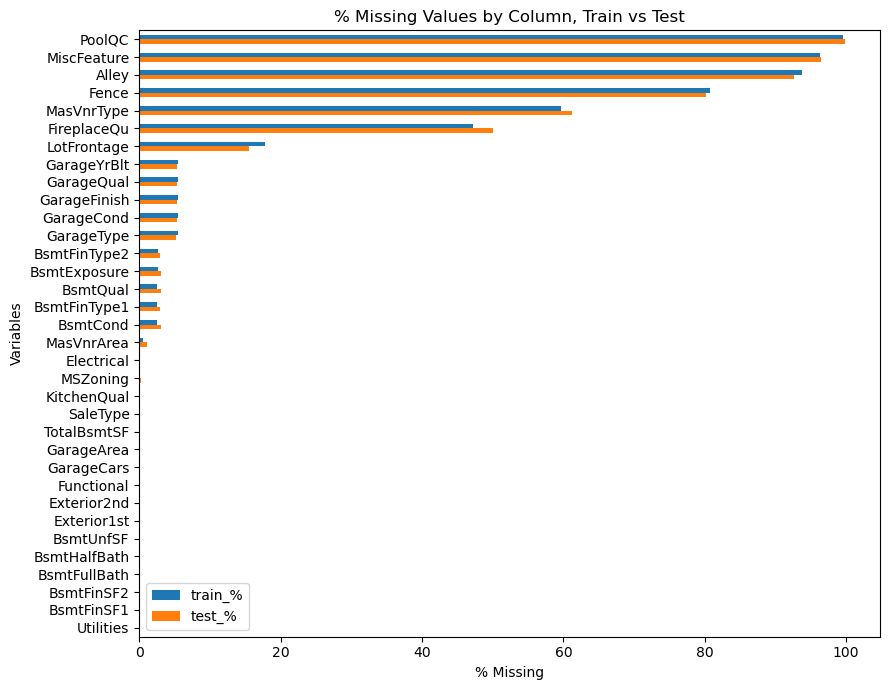

34 columns have at least one missing value in train or test dataset.


In [70]:
# Calculate the percentage of missing values for each column
miss_train = train_df.isnull().mean() * 100
miss_test = test_df.isnull().mean() * 100

# Combine the two Series into one DataFrame
miss_compare = pd.DataFrame({'train_%': miss_train, 'test_%': miss_test})

# Filter for columns with missing data and sort by descending order
miss_compare = miss_compare[(miss_compare['train_%'] > 0) | (miss_compare['test_%'] > 0)]
miss_compare = miss_compare.sort_values('train_%', ascending=False)

# Visualize using a horizontal bar graph
fig, ax = plt.subplots(figsize=(9, 7))
miss_compare.plot(kind='barh', ax=ax)
ax.set_xlabel("% Missing")
ax.set_ylabel("Variables")
ax.set_title("% Missing Values by Column, Train vs Test")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"{len(miss_compare)} columns have at least one missing value in train or test dataset.")

Most of the columns at the top (**PoolQC**, **MiscFeature**, **Alley**, **Fence**, **MasVnrType**, **FireplaceQu**) aren't really *missing* data, the feature just doesn't apply to that house (no pool, no alley, etc). This is explicitly stated in the *data_description.txt* file. Those get filled with 0 or 'None' rather than median or mean. A smaller set (**Electrical**, **MSZoning**, **KitchenQual**...) are genuine one-off gaps, and get filled with their respective modes.

For Garage and Basement, we probe to check if the missingness is due to structural absences or if they are genuinely unrecorded.

There are true missing data in **LotFrontage**, because every house sits on a physical piece of land. This means that it is impossible for a house to have absolutely zero lot frontage.

Missing values are dealt with later in the script.

#### Garage

In [71]:
# Garage
# Filter for houses that physically have no garage
no_garage = train_df[train_df['GarageArea'] == 0]
print(f"There are {no_garage.shape[0]} properties with no basement.")

# Check how many of these houses are 'missing' their garage quality ratings
print(no_garage[['GarageQual', 'GarageCond', 'GarageType']].isnull().sum())

# Find houses that HAVE a garage, but are missing the quality rating
basement_anomaly = train_df[(train_df['GarageArea'] > 0) & (train_df['GarageQual'].isnull())]
print(basement_anomaly[['GarageArea', 'GarageQual']])

There are 81 properties with no basement.
GarageQual    81
GarageCond    81
GarageType    81
dtype: int64
Empty DataFrame
Columns: [GarageArea, GarageQual]
Index: []


#### Basement

In [72]:
# Basement
# Filter for houses that physically have no basement
no_basement = train_df[train_df['TotalBsmtSF'] == 0]
print(f"There are {no_basement.shape[0]} properties with no basement.")

# Check how many of these houses are 'missing' their basement quality ratings
print(no_basement[['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']].isnull().sum())

# Find houses that HAVE a basement, but are missing the quality rating
basement_anomaly = train_df[(train_df['TotalBsmtSF'] > 0) & (train_df['BsmtQual'].isnull())]
print(basement_anomaly[['TotalBsmtSF', 'BsmtQual']])

There are 37 properties with no basement.
BsmtQual        37
BsmtCond        37
BsmtExposure    37
BsmtFinType1    37
BsmtFinType2    37
dtype: int64
Empty DataFrame
Columns: [TotalBsmtSF, BsmtQual]
Index: []


We mathematically verified the structural missingness for the Garage and Basement categories; by isolating properties with exactly zero physical square footage (e.g., **GarageArea** == 0) and summing the NaN values in their corresponding categorical columns, we proved that these missing quality ratings perfectly aligned with the physical absence of the structures themselves.

#### LotFrontage

LotFrontage
NaN      259
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
137.0      1
38.0       1
33.0       1
150.0      1
46.0       1
Name: count, Length: 111, dtype: int64


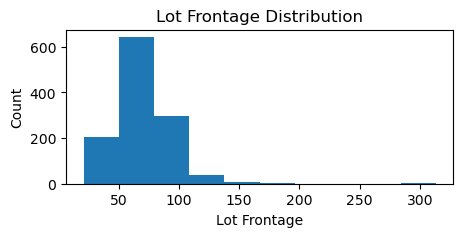

In [73]:
# LotFrontage

# 'LotFrontage' is Missing at Random (MAR); the variable can be explained by other variables such as 'Neighborhood'
# The histogram shows that the distribution is heavily right-skewed. Therefore, we will use median to replace the missing values.
# Later in the script, we will group by Neighborhood and fill the 259 missing LotFrontage values with the median of each group
print(train_df["LotFrontage"].value_counts(dropna=False))

plt.figure(figsize=(5,2))
plt.hist(train_df["LotFrontage"], bins=10)
plt.xlabel("Lot Frontage")
plt.ylabel("Count")
plt.title("Lot Frontage Distribution")
plt.show()

### 3. Exploring and Visualizing Outliers

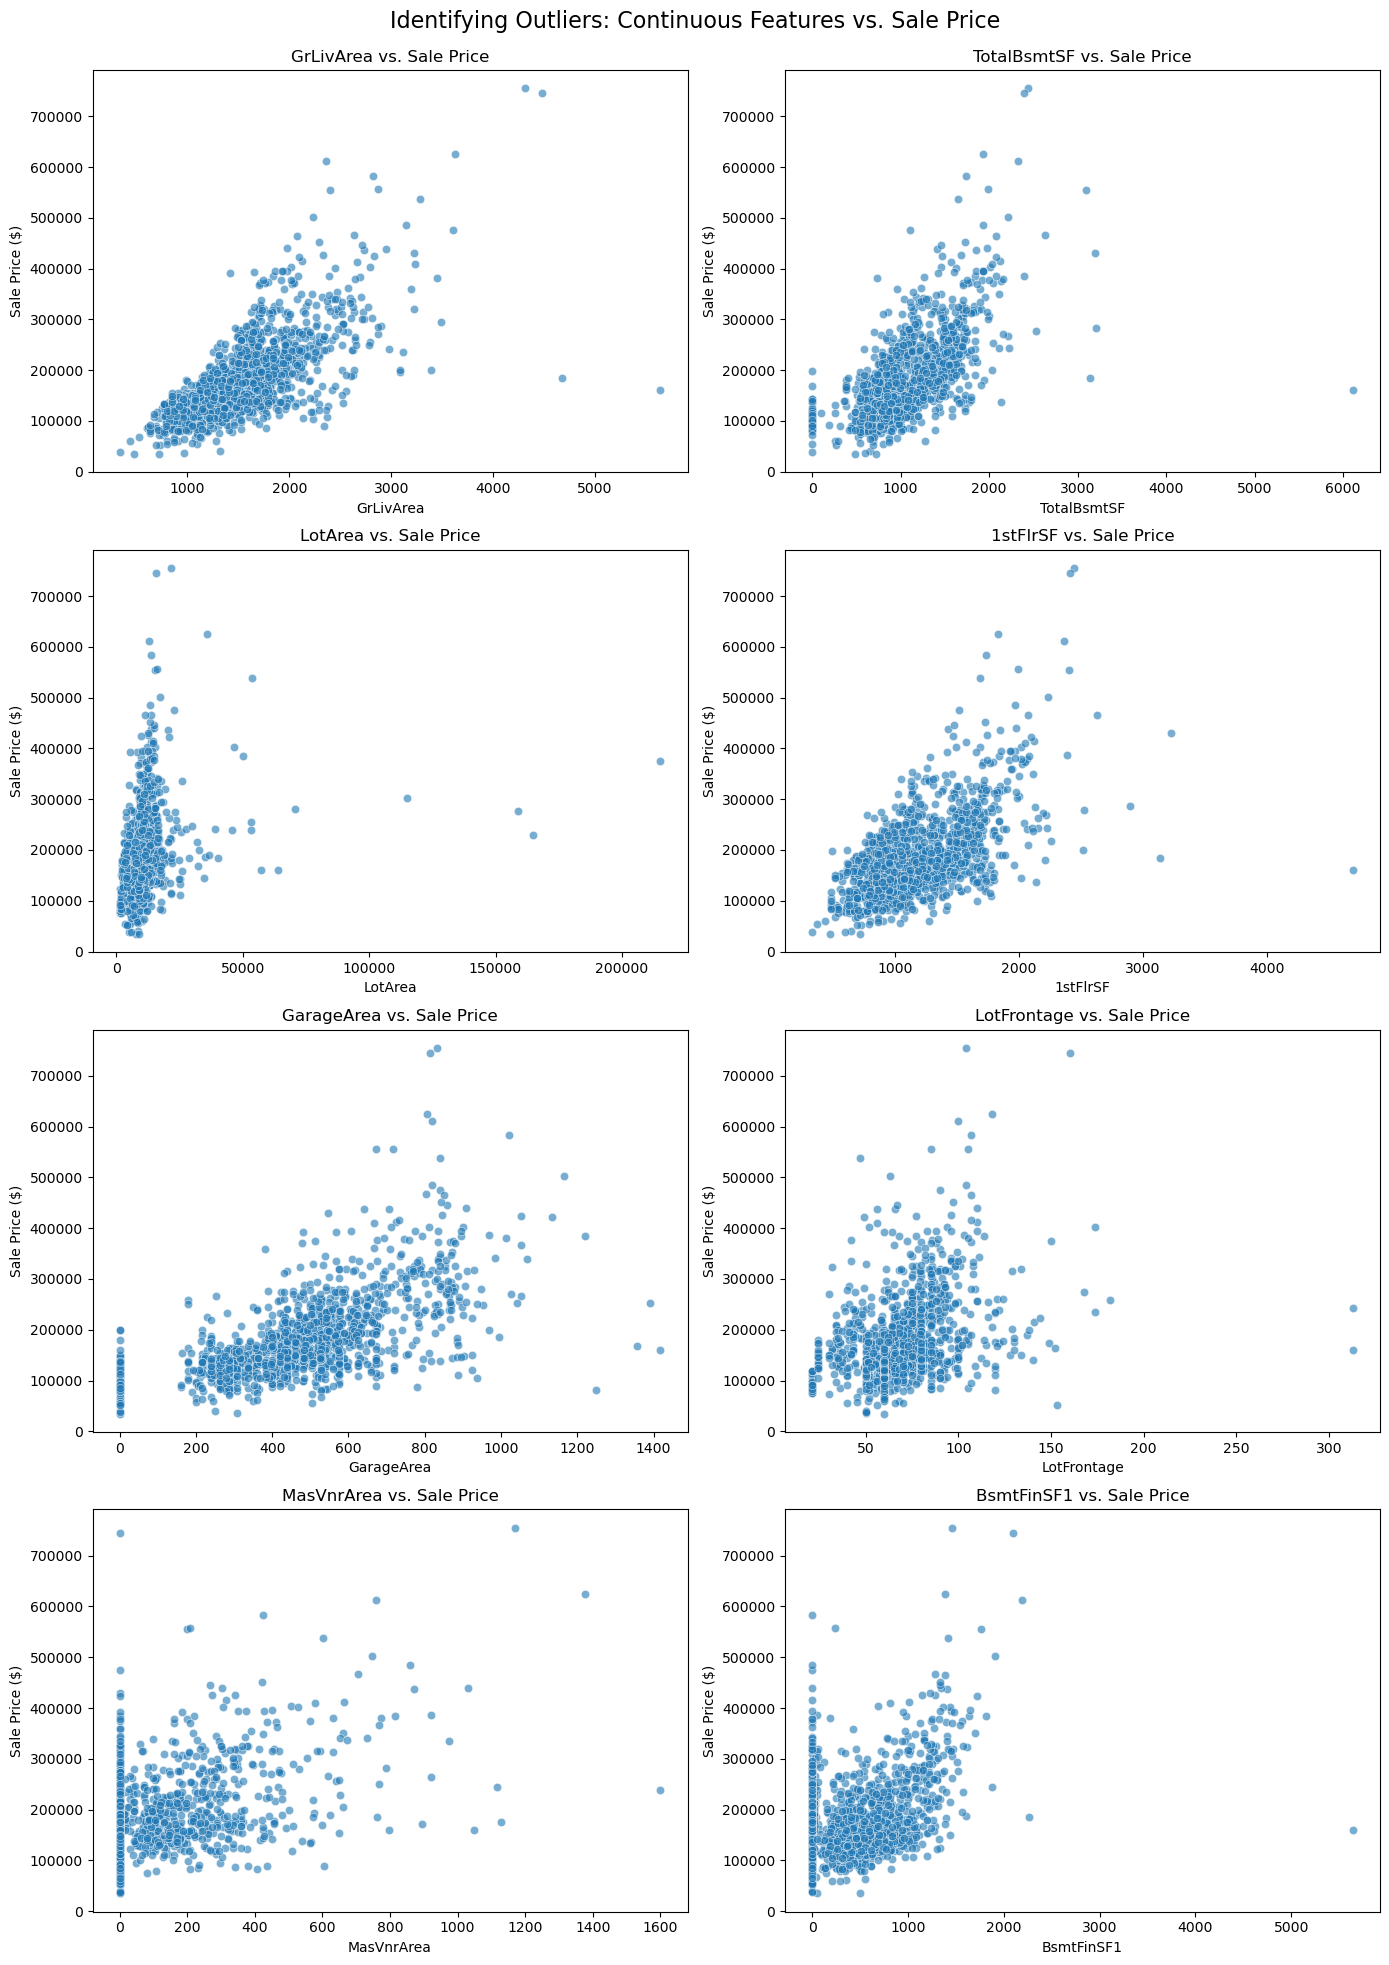

In [74]:
# Group the continuous variables
continuous_variables = [
    "GrLivArea", "TotalBsmtSF", "LotArea", "1stFlrSF", 
    "GarageArea", "LotFrontage", "MasVnrArea", "BsmtFinSF1"
]

# Expand the grid to 4 rows and 2 columns to fit all 8 variables
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
fig.suptitle('Identifying Outliers: Continuous Features vs. Sale Price', fontsize=16)

axes = axes.flatten()

for i, feature in enumerate(continuous_variables):
    sns.scatterplot(x=train_df[feature], y=train_df['SalePrice'], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{feature} vs. Sale Price')
    axes[i].set_ylabel('Sale Price ($)')
    # Removed '(sq ft)' since LotFrontage is in linear feet
    axes[i].set_xlabel(f'{feature}') 

# Adjust layout to prevent overlapping labels and give the title space
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [75]:
# Delete Outliers

# 1. The Living Area & Basement Monsters
outliers_liv = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
train_df = train_df.drop(outliers_liv)

# 2. The Agricultural / Massive Lot Anomalies
outliers_lot = train_df[train_df['LotArea'] > 100000].index
train_df = train_df.drop(outliers_lot)

# 3. The Garage and Frontage Anomalies
outliers_garage = train_df[(train_df['GarageArea'] > 1200) & (train_df['SalePrice'] < 300000)].index
train_df = train_df.drop(outliers_garage)
outliers_frontage = train_df[train_df['LotFrontage'] > 300].index
train_df = train_df.drop(outliers_frontage)

# 4. The Final Masonry & Finished Basement Anomalies
outliers_masonry = train_df[train_df['MasVnrArea'] > 1400].index
train_df = train_df.drop(outliers_masonry)
outliers_bsmt = train_df[train_df['BsmtFinSF1'] > 4000].index
train_df = train_df.drop(outliers_bsmt)

# Reset the index cleanly after all drops
train_df = train_df.reset_index(drop=True)
print(f"Dataset completely sterilized. Final training set shape: {train_df.shape}")

Dataset completely sterilized. Final training set shape: (1449, 80)


### Data Cleaning and Feature Engineering

#### Rare Categories and Dimensionality

A category that shows up once or twice across the whole dataset (a roof material used on a single house, say) doesn't give a model enough examples to learn anything reliable from it. Grouping anything under 10 total occurrences (train + test combined) into one shared 'Rare' level instead.

In [76]:
# Define the grouping function
def group_rare_categories(train_df, test_df, cat_cols, min_freq=10):
    combined = pd.concat([train_df, test_df])
    grouped_report = {}
    for col in cat_cols:
        counts = combined[col].value_counts()
        rare = counts[counts < min_freq].index.tolist()
        if rare:
            grouped_report[col] = rare
        train_df[col] = train_df[col].apply(lambda x: 'Rare' if x in rare else x)
        test_df[col] = test_df[col].apply(lambda x: 'Rare' if x in rare else x)
    return train_df, test_df, grouped_report

# Assign the nominal columns to a list
nominal_cols = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
    'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating',
    'CentralAir', 'Electrical', 'GarageType', 'GarageFinish', 'PavedDrive',
    'MiscFeature', 'SaleType', 'SaleCondition'
]

# Feed the train, test, and nominal columns into the function and assign the values
train_df, test_df, grouped_report = group_rare_categories(train_df, test_df, nominal_cols, min_freq=10)

print(f"Grouped rare values in {len(grouped_report)} of {len(nominal_cols)} columns:\n")
for col, vals in grouped_report.items():
    print(f"  {col}: {vals}")

Grouped rare values in 14 of 29 columns:

  MSSubClass: [40, 150]
  Utilities: ['NoSeWa']
  Condition1: ['RRNn', 'RRNe']
  Condition2: ['Artery', 'PosA', 'PosN', 'RRNn', 'RRAn', 'RRAe']
  HouseStyle: ['2.5Fin']
  RoofStyle: ['Shed']
  RoofMatl: ['WdShake', 'WdShngl', 'Metal', 'Membran', 'Roll']
  Exterior1st: ['BrkComm', 'AsphShn', 'Stone', 'CBlock', 'ImStucc']
  Exterior2nd: ['Stone', 'AsphShn', 'CBlock', 'Other']
  Foundation: ['Wood']
  Heating: ['Grav', 'Wall', 'OthW', 'Floor']
  Electrical: ['FuseP', 'Mix']
  MiscFeature: ['Gar2', 'Othr', 'TenC']
  SaleType: ['ConLI', 'ConLw', 'Oth', 'Con']


#### Imputation, Aggregation, Interaction, and Temporal Features

In [77]:
def clean_housing_data(df, skewed_cols=None):
    """
    Cleans, maps, and imputes missing values for the Ames Housing dataset.
    """
    # Create a copy to avoid SettingWithCopy warnings and mutating the original dataset
    df = df.copy()

    # 1. Basic Numeric Imputation
    # For these features, a missing value implies the absence of the structure (e.g., no basement, no garage)
    rogue_num_cols = [
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
    ]
    df[rogue_num_cols] = df[rogue_num_cols].fillna(0)

    # Basic Categorical Imputation
    # Kitchen and utility functionality are required features; assume the most common (mode) if missing
    rogue_cat_cols = ['KitchenQual', 'Functional']
    for col in rogue_cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Grouped Imputation
    # Impute LotFrontage using the median value as proposed above
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

    # NA in Alley means no alley access, not missing data
    df["Alley"] = df["Alley"].fillna('None')

    # Logical Anomaly Correction: Masonry Veneer
    # Fix rows where an area exists but the type is missing by assigning the most common type
    veneer_anomaly = (df['MasVnrArea'] > 0) & (df['MasVnrType'].isnull())
    df.loc[veneer_anomaly, 'MasVnrType'] = df['MasVnrType'].mode()[0]
    
    # Handle genuine missing values (no veneer)
    df['MasVnrType'] = df['MasVnrType'].fillna('None')
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0.0)

    # Missing electrical systems default to the most common setup
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

    # MSSubClass is a categorical building code, not a numeric measurement. Cast to string for dummy encoding later.
    df["MSSubClass"] = df["MSSubClass"].astype(str).str.strip()

    # Feature Engineering: Time
    # Convert absolute years into relative age (years since built/remodeled). 
    # Relative age is much more effective for regression models than raw calendar years.
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df = df.drop(columns=["YearBuilt", "YearRemodAdd"])

    # Ordinal Data Formatting
    # Standardize string formatting to ensure mapping dictionaries apply perfectly
    ordinal_cols_to_strip = [
        'ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual',
        'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtFinType1',
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure'
    ]
    for col in ordinal_cols_to_strip:
        df[col] = df[col].str.capitalize().str.strip()

    # Ordinal Encoding
    # Convert categorical quality rankings into mathematical hierarchies
    quality_map = {'Ex': 5, 'Gd': 4, 'Ta': 3, 'Fa': 2, 'Po': 1}
    standard_ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
    for col in standard_ord_cols:
        df[col] = df[col].map(quality_map)

    type_map = {'Glq': 6, 'Alq': 5, 'Blq': 4, 'Rec': 3, 'Lwq': 2, 'Unf': 1}
    for col in ["BsmtFinType1", "BsmtFinType2"]:
        df[col] = df[col].map(type_map)

    func_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
    df["Functional"] = df["Functional"].map(func_map)

    fence_map = {'Gdprv': 4, 'Mnprv': 3, 'Gdwo': 2, 'Mnww': 1}
    df["Fence"] = df["Fence"].map(fence_map)

    exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1}
    df["BsmtExposure"] = df["BsmtExposure"].map(exposure_map)

    # Logical Anomaly Correction: Basements
    # If total basement square footage > 0 but qualities are missing, impute with mode.
    # Otherwise, fill completely missing basements with 0 (since they are now numeric ordinal columns).
    bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    for col in bsmt_cols:
        anomaly = (df['TotalBsmtSF'] > 0) & (df[col].isnull())
        df.loc[anomaly, col] = df[col].mode()[0]
    df[bsmt_cols] = df[bsmt_cols].fillna(0)

    # Logical Anomaly Correction: Fireplaces
    fire_anomaly = (df['Fireplaces'] > 0) & (df['FireplaceQu'].isnull())
    df.loc[fire_anomaly, 'FireplaceQu'] = df['FireplaceQu'].mode()[0]
    df['FireplaceQu'] = df['FireplaceQu'].fillna(0)

    # Logical Anomaly Correction: Garages
    garage_ordinal_cols = ['GarageQual', 'GarageCond']
    for col in garage_ordinal_cols:
        anomaly = (df['GarageArea'] > 0) & (df[col].isnull())
        df.loc[anomaly, col] = df[col].mode()[0]
    df[garage_ordinal_cols] = df[garage_ordinal_cols].fillna(0)

    # Handle nominal garage features (NA means no garage)
    garage_cat_cols = ['GarageType', 'GarageFinish']
    df[garage_cat_cols] = df[garage_cat_cols].fillna('None')

    # If the garage year built is missing, assume it was built at the same time as the house
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YrSold'] - df['HouseAge'])

    # Logical Anomaly Correction: Pools & Misc Features
    pool_anomaly = (df['PoolArea'] > 0) & (df['PoolQC'].isnull())
    if not df[pool_anomaly].empty:
        df.loc[pool_anomaly, 'PoolQC'] = df['PoolQC'].mode()[0]
    df['PoolQC'] = df['PoolQC'].fillna(0)

    df['Fence'] = df['Fence'].fillna(0)

    misc_anomaly = (df['MiscVal'] > 0) & (df['MiscFeature'].isnull())
    if not df[misc_anomaly].empty:
        df.loc[misc_anomaly, 'MiscFeature'] = df['MiscFeature'].mode()[0]
    df['MiscFeature'] = df['MiscFeature'].fillna('None')

    # Advanced Feature Engineering
    # Combine individual floors and basement into a single total square footage metric
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    # Create an interaction term: heavily rewards houses that are both large AND high quality
    df['QualitySF'] = df['OverallQual'] * df['GrLivArea']

    # Skewness Correction
    # Apply log(1+x) transformation to heavily right-skewed columns to normalize their distributions.
    # The clip(lower=0) ensures we don't pass negative values into the log function.
    if skewed_cols is not None:
        for col in skewed_cols:
            if col in df.columns:
                df[col] = np.log1p(df[col].clip(lower=0))

    # Nominal Encoding
    # Convert all remaining nominal categorical variables (strings) into binary columns.
    # drop_first=True prevents perfect multicollinearity (the dummy variable trap).
    df = pd.get_dummies(df, drop_first=True, dtype=int)

    # Final Type Casting
    # Ensure all numerical data is consistent for scikit-learn processing
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df[numeric_cols] = df[numeric_cols].astype('float64')

    return df

#### Skewness

Checking skewness on every continuous predictor, using train data only so nothing from test leaks into the decision, then applying the same log transform to both sides.

In [78]:
# Probe to see which columns are skewed
candidate_skew_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'QualitySF'
]

train_probe = clean_housing_data(train_df)
skew_before = {c: skew(train_probe[c]) for c in candidate_skew_cols if c in train_probe.columns}
skewed_cols = [c for c, s in skew_before.items() if abs(s) > 0.75]
for col in skewed_cols:
    print("Log-transforming:", col)


Log-transforming: LotArea
Log-transforming: MasVnrArea
Log-transforming: BsmtFinSF1
Log-transforming: BsmtFinSF2
Log-transforming: BsmtUnfSF
Log-transforming: 1stFlrSF
Log-transforming: 2ndFlrSF
Log-transforming: LowQualFinSF
Log-transforming: GrLivArea
Log-transforming: WoodDeckSF
Log-transforming: OpenPorchSF
Log-transforming: EnclosedPorch
Log-transforming: 3SsnPorch
Log-transforming: ScreenPorch
Log-transforming: PoolArea
Log-transforming: MiscVal
Log-transforming: TotalSF
Log-transforming: QualitySF


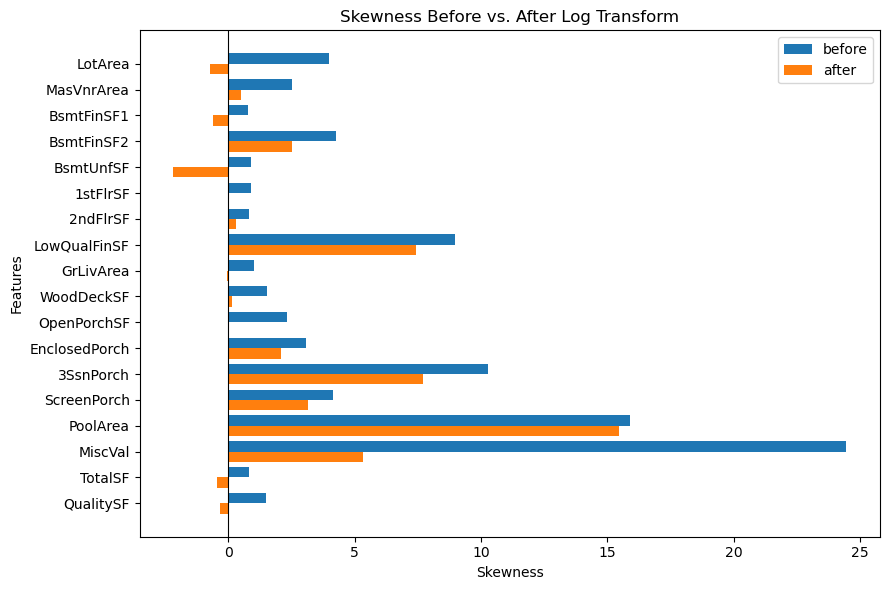

In [79]:
# Visualize what would happen to skewness after applying log
skew_after = {c: skew(np.log1p(train_probe[c].clip(lower=0))) for c in skewed_cols}

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(skewed_cols))
ax.barh(y_pos - 0.2, [skew_before[c] for c in skewed_cols], height=0.4, label='before')
ax.barh(y_pos + 0.2, [skew_after[c] for c in skewed_cols], height=0.4, label='after')
ax.set_yticks(y_pos)
ax.set_yticklabels(skewed_cols)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Skewness")
ax.set_ylabel("Features")
ax.set_title("Skewness Before vs. After Log Transform")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [80]:
# Feed both Training and Testing data into the function for cleaning/engineering
train_clean = clean_housing_data(train_df, skewed_cols=skewed_cols)
test_clean = clean_housing_data(test_df, skewed_cols=skewed_cols)

print("train_clean:", train_clean.shape)
print("test_clean: ", test_clean.shape)
print("Any nulls left:", train_clean.isnull().values.any(), test_clean.isnull().values.any())

train_clean: (1449, 200)
test_clean:  (1459, 197)
Any nulls left: False False


In [81]:
# Align Train and Test DataFrames to ensure they possess the exact same columns
print("Before align:")
print("X_train:", train_clean.drop(columns=['SalePrice']).shape)
print("X_test: ", test_clean.shape)

y_train = train_clean['SalePrice']
X_train = train_clean.drop(columns=['SalePrice'])
X_test = test_clean.copy()
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print()
print("After align:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

Before align:
X_train: (1449, 199)
X_test:  (1459, 197)

After align:
X_train: (1449, 199)
X_test:  (1459, 199)


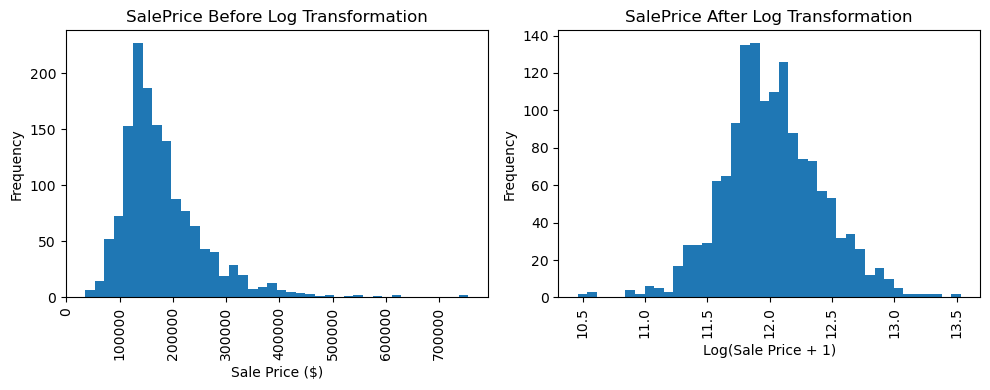

In [82]:
# Check the distribution of SalePrice, and log if necessary

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before Transform
axes[0].hist(y_train, bins=40)
axes[0].set_title("SalePrice Before Log Transformation")
axes[0].set_xlabel("Sale Price ($)")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

y_train_log = np.log1p(y_train)

# After Transform
axes[1].hist(y_train_log, bins=40)
axes[1].set_title("SalePrice After Log Transformation")
axes[1].set_xlabel("Log(Sale Price + 1)")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

# Ensures the vertical labels don't get cut off at the bottom
plt.tight_layout()
plt.show()

### Modeling

#### Standard OLS

In [83]:
# Define a function to calculate the Root Mean Squared Error score; 10 splits
kf = KFold(n_splits=10, shuffle=True, random_state=42)
def rmse_cv(model, X, y):
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kf)
    return np.sqrt(-scores)

In [84]:
# Model the standard OLS and return the RMSE value
ols = LinearRegression()
ols_scores = rmse_cv(ols, X_train, y_train_log)
print(f"OLS   RMSE: {ols_scores.mean():.5f}")

OLS   RMSE: 0.11621


#### Ridge

In [85]:
# Apply Ridge on unscaled data
# Test 100 different penalty values (alphas) on unscaled X_train data first to find the optimal alpha
ridge_probe = RidgeCV(alphas=np.logspace(-2, 3, 100), cv=kf).fit(X_train, y_train_log)
ridge_unscaled = rmse_cv(RidgeCV(alphas=[ridge_probe.alpha_]), X_train, y_train_log).mean()

# Apply Ridge on scaled data
# Test 100 different penalty values (alphas) on scaled X_train data first to find the optimal alpha
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
ridge_probe_s = RidgeCV(alphas=np.logspace(-2, 3, 100), cv=kf).fit(X_train_scaled, y_train_log)
ridge_scaled = rmse_cv(RidgeCV(alphas=[ridge_probe_s.alpha_]), X_train_scaled, y_train_log).mean()

print(f"Ridge unscaled: {ridge_unscaled:.5f}")
print(f"Ridge scaled:   {ridge_scaled:.5f}")

Ridge unscaled: 0.11175
Ridge scaled:   0.11412


Scaling came out slightly worse here with RMSE of 0.11412, compared to RMSE of 0.11175 of the unscaled data. This is because most of the columns are dummy variables, with binary values of 0 or 1. Also, the continuous variables' range was compressed during the log-transformation.

#### LASSO

In [86]:
# Apply LASSO on unscaled data. Set max_iter=50000 so the algorithm does not prematurely end
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=kf, max_iter=50000, random_state=42)
lasso_cv.fit(X_train, y_train_log)
lasso_scores = rmse_cv(LassoCV(alphas=[lasso_cv.alpha_], max_iter=50000), X_train, y_train_log)

print(f"Lasso RMSE: {lasso_scores.mean():.5f}  (alpha={lasso_cv.alpha_:.5f})")
print(f"Lasso zeroed out {(lasso_cv.coef_ == 0).sum()} of {len(lasso_cv.coef_)} features")


Lasso RMSE: 0.11099  (alpha=0.00011)
Lasso zeroed out 42 of 199 features


In [87]:
# Print to view the first three rows of both train and test DataFrames
train_clean.head(3)

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,SalePrice,HouseAge,RemodelAge,TotalSF,QualitySF,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Rare,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_Rare,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_Rare,Condition2_Norm,Condition2_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_Rare,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Rare,RoofMatl_Rare,RoofMatl_Tar&Grv,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,Foundation_Stone,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,Heating_GasW,Heating_Rare,CentralAir_Y,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,MiscFeature_Rare,MiscFeature_Shed,SaleType_CWD,SaleType_ConLD,SaleType_New,SaleType_Rare,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,9.042040,7.0,5.0,5.283204,4.0,3.0,4.0,1.0,6.0,6.561031,1.0,0.0,5.017280,856.0,5.0,6.753438,6.751101,0.0,7.444833,1.0,0.0,2.0,1.0,3.0,1.0,4.0,8.0,7.0,0.0,0.0,2003.0,2.0,548.0,3.0,3.0,0.000000,4.127134,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2008.0,208500.0,5.0,5.0,7.850493,9.390242,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
1,80.0,9.169623,6.0,8.0,0.000000,3.0,3.0,4.0,4.0,5.0,6.886532,1.0,0.0,5.652489,1262.0,5.0,7.141245,0.000000,0.0,7.141245,0.0,1.0,2.0,0.0,3.0,1.0,3.0,6.0,7.0,1.0,3.0,1976.0,2.0,460.0,3.0,3.0,5.700444,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2007.0,181500.0,31.0,31.0,7.833996,8.932345,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0

In [88]:
# Print to view the first three rows of both train and test DataFrames
test_clean.head(3)

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,HouseAge,RemodelAge,TotalSF,QualitySF,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_Rare,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_Rare,Condition2_Norm,Condition2_Rare,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Rare,RoofMatl_Rare,RoofMatl_Tar&Grv,Exterior1st_BrkFace,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Rare,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Plywood,Exterior2nd_Rare,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Rare,Foundation_Slab,Foundation_Stone,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,Heating_GasW,Heating_Rare,CentralAir_Y,Electrical_FuseF,Electrical_Rare,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,MiscFeature_Rare,MiscFeature_Shed,SaleType_CWD,SaleType_ConLD,SaleType_New,SaleType_Rare,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,80.0,9.360741,5.0,6.0,0.000000,3.0,3.0,3.0,1.0,3.0,6.150603,2.0,4.976734,5.602119,882.0,3.0,6.799056,0.000000,0.0,6.799056,0.0,0.0,1.0,0.0,2.0,1.0,3.0,5.0,7.0,0.0,0.0,1961.0,1.0,730.0,3.0,3.0,4.948760,0.000000,0.0,0.0,4.795791,0.0,0.0,3.0,0.000000,6.0,2010.0,49.0,49.0,7.483807,8.407602,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0
1462,81.0,9.565775,6.0,6.0,4.691348,3.0,3.0,3.0,1.0,5.0,6.828712,1.0,0.000000,6.008813,1329.0,3.0,7.192934,0.000000,0.0,7.192934,0.0,0.0,1.0,1.0,3.0,1.0,4.0,6.0,7.0,0.0,0.0,1958.0,1.0,312.0

In [89]:
# Check the engineered Train data
print(train_clean.info())
print("")
print(train_clean.isnull().values.any())
print("")
print(train_clean.columns)
print("")
print(train_clean.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Columns: 200 entries, LotFrontage to SaleCondition_Partial
dtypes: float64(52), int32(148)
memory usage: 1.4 MB
None

False

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1',
       ...
       'SaleType_CWD', 'SaleType_ConLD', 'SaleType_New', 'SaleType_Rare',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=200)

(1449, 200)


In [90]:
# Check the engineered Test data
print(test_clean.info())
print("")
print(test_clean.isnull().values.any())
print("")
print(test_clean.columns)
print("")
print(test_clean.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Columns: 197 entries, LotFrontage to SaleCondition_Partial
dtypes: float64(51), int32(146)
memory usage: 1.4 MB
None

False

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1',
       ...
       'SaleType_CWD', 'SaleType_ConLD', 'SaleType_New', 'SaleType_Rare',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=197)

(1459, 197)


In [91]:
# Problem: The number of columns in the test set does not match that in the train set.
# Reason: This is because pd.get_dummies() creates binary columns based only on the unique categories present in the current dataset. 
# If the training data contains a specific category (e.g., a rare Roof Material) that is completely absent from the testing data, the 
# testing dataset will not generate that specific dummy column, causing a matrix shape mismatch when we run our regression model.

# Solution: We use .align() to fill missing categories in the testing data with 0

# Isolate the target variable (Y) from the training set
y_train = train_clean['SalePrice']

# Isolate the predictor variables (X)
X_train = train_clean.drop(columns=['SalePrice'])
X_test = test_clean.copy()

# Align the columns so X_test perfectly matches the shape of X_train
# Any dummy columns present in train but missing in test will be added and filled with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Verification
print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape:  {X_test.shape}")

Final X_train shape: (1449, 199)
Final X_test shape:  (1459, 199)


## Modeling

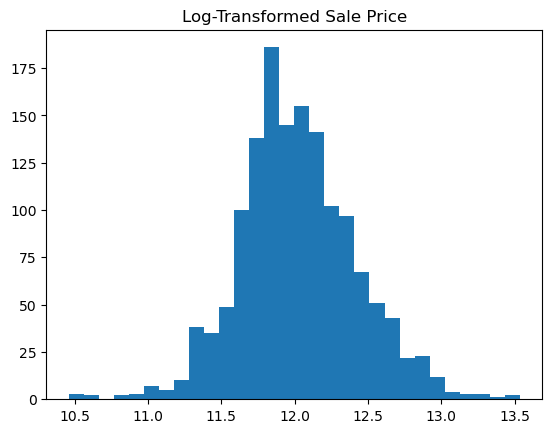

In [92]:
# Apply a natural logarithm to the target variable
y_train_log = np.log(y_train)

plt.hist(y_train_log, bins=30)
plt.title("Log-Transformed Sale Price")
plt.show()

In [93]:
# Scale the features for Ridge and LASSO application
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
# Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Function to calculate the average Cross-Validation RMSE
def get_rmse(model):
    # cross_val_score returns negative MSE, so we invert and square root it
    mse = -cross_val_score(model, X_train_scaled, y_train_log, scoring="neg_mean_squared_error", cv=kf)
    return np.sqrt(mse).mean()

In [95]:
# Fit Models

# OLS
ols = LinearRegression()
print(f"OLS RMSE: {get_rmse(ols):.4f}")

# Ridge (L2 Penalty)
# Tests 100 alpha values between 0.1 and 1000 to find the optimal penalty
ridge = RidgeCV(alphas=np.logspace(-1, 3, 100), cv=kf)
ridge.fit(X_train_scaled, y_train_log)
best_ridge = Ridge(alpha=ridge.alpha_)
print(f"Ridge RMSE: {get_rmse(best_ridge):.4f} (Optimal Alpha: {ridge.alpha_:.2f})")

# LASSO (L1 Penalty)
# Tests 100 alpha values between 0.0001 and 0.1
lasso = LassoCV(alphas=np.logspace(-4,-1,100), cv=kf, max_iter=10000)
lasso.fit(X_train_scaled, y_train_log)
best_lasso = Lasso(alpha=lasso.alpha_, max_iter=10000)
print(f"LASSO RMSE: {get_rmse(best_lasso):.4f} (Optimal Alpha: {lasso.alpha_:.2f})")

OLS RMSE: 15880723774.1655
Ridge RMSE: 0.1159 (Optimal Alpha: 155.57)
LASSO RMSE: 0.1134 (Optimal Alpha: 0.00)


In [96]:
# Feature Engineering

def add_interaction_terms(df):
    df = df.copy()

    # Total Square Footage: Aggregate 1stFlrSF, 2ndfFlrSF, and TotalBsmtSF
    df["TotalSqFt"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    # Overall Quality * Total Square Footage
    df["Qual_x_SqFt"] = df["OverallQual"] * df["TotalSqFt"]

    # Total Bathrooms
    df["TotalBaths"] = df["FullBath"] + (0.5 * df["HalfBath"]) + df["BsmtFullBath"] + (0.5 * df["BsmtHalfBath"])

    # Total Outdoor Space
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]

    # Age and Remodel (This captures the penalty of an old house that hasn't been updated)
    df["Age_x_Remodel"] = df["HouseAge"] * df["RemodelAge"]

    # Drop original columns
    cols_to_drop = ["1stFlrSF", "2ndFlrSF", "TotalBsmtSF", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]
    df = df.drop(columns=cols_to_drop)
    
    return df

# Execute the feature engineering
train_clean = add_interaction_terms(train_clean)
test_clean = add_interaction_terms(test_clean)

In [97]:
# Isolate the target variable (Y) from the training set
y_train = train_clean['SalePrice']

# Isolate the predictor variables (X)
X_train = train_clean.drop(columns=['SalePrice'])
X_test = test_clean.copy()

# Align the columns so X_test perfectly matches the shape of X_train
# Any dummy columns present in train but missing in test will be added and filled with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Apply a natural logarithm to the target variable
y_train_log = np.log(y_train)

# Scale the features for Ridge and LASSO application
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge (L2 Penalty)
# Tests 100 alpha values between 0.1 and 1000 to find the optimal penalty
ridge = RidgeCV(alphas=np.logspace(-1, 3, 100), cv=kf)
ridge.fit(X_train_scaled, y_train_log)
best_ridge = Ridge(alpha=ridge.alpha_)
print(f"Ridge RMSE: {get_rmse(best_ridge):.4f} (Optimal Alpha: {ridge.alpha_:.2f})")

# LASSO (L1 Penalty)
# Tests 100 alpha values between 0.0001 and 0.1
lasso = LassoCV(alphas=np.logspace(-4,-1,100), cv=kf, max_iter=10000)
lasso.fit(X_train_scaled, y_train_log)
best_lasso = Lasso(alpha=lasso.alpha_, max_iter=10000)
print(f"LASSO RMSE: {get_rmse(best_lasso):.4f} (Optimal Alpha: {lasso.alpha_:.2f})")

Ridge RMSE: 0.1148 (Optimal Alpha: 129.15)
LASSO RMSE: 0.1124 (Optimal Alpha: 0.00)


In [98]:
import xgboost as xgb
import numpy as np

# 1. Initialize the XGBoost Regressor
# We use reg:squarederror to align with our RMSE goal
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4
)

# 2. Run Cross-Validation on the sterilized matrix
# (Note: XGBoost doesn't strictly need the scaled data, but using X_train_scaled is perfectly fine)
xgb_scores = cross_val_score(
    xgb_model, 
    X_train_scaled, 
    y_train_log, 
    scoring='neg_root_mean_squared_error', 
    cv=kf
)

# 3. Calculate Average RMSE
xgb_rmse = -xgb_scores.mean()

print(f"Baseline XGBoost RMSE: {xgb_rmse:.4f}")

Baseline XGBoost RMSE: 0.1191


In [99]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid to test
param_grid = {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [500, 1000],
        'subsample': [0.8, 1.0]
}

# 2. Initialize a fresh baseline model
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 3. Run the exhaustive grid search
grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring='neg_root_mean_squared_error',
        cv=kf,
        verbose=1,
        n_jobs=-1 # Uses all available CPU cores to speed up the search
)

# 4. Fit the grid to the training data
grid_search.fit(X_train_scaled, y_train_log)

# 5. Extract the best model and score
best_xgb_rmse = -grid_search.best_score_
print(f"\nTuned XGBoost RMSE: {best_xgb_rmse:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Tuned XGBoost RMSE: 0.1151
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.8}


In [100]:
# Fit the winning LASSO model on the fully sterilized, scaled training data
final_lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=kf, max_iter=10000)
final_lasso.fit(X_train_scaled, y_train_log)

# Generate predictions on the unseen test set
log_predictions = final_lasso.predict(X_test_scaled)

# Reverse the log transformation to convert predictions back to real dollar amounts
final_predictions = np.exp(log_predictions)

# Package into Kaggle's required format
submission = pd.DataFrame({
    'Id': test_df.index,  # Assuming Kaggle's 'Id' column is set as the index of test_df
    'SalePrice': final_predictions
})

# Export to CSV
submission.to_csv('submission.csv', index=False)
print(f"Submission saved! Final LASSO Alpha used: {final_lasso.alpha_:.4f}")

Submission saved! Final LASSO Alpha used: 0.0029


In [101]:
# 1. Generate predictions from your tuned XGBoost model
xgb_log_predictions = grid_search.predict(X_test_scaled)
xgb_predictions = np.exp(xgb_log_predictions)

# 2. Blend the models (e.g., 70% LASSO for accuracy on normal homes, 30% XGBoost as a safety net for outliers)
blended_predictions = (0.70 * final_predictions) + (0.30 * xgb_predictions)

# 3. Package the Blended Predictions
submission_blend = pd.DataFrame({
    'Id': test_df.index,
    'SalePrice': blended_predictions
})

# 4. Export to CSV
submission_blend.to_csv('ames_blended_submission.csv', index=False)
print("Blended ensemble successfully exported to CSV!")

Blended ensemble successfully exported to CSV!
